In [17]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import astropy.wcs.wcs as wcs
import glob
import os
import pandas as pd

from create_figs import create_m8_map

In [7]:
import warnings
warnings.filterwarnings("ignore")

This notebook demonstrates some exploratory analysis of HOPS-203 12CO data cube, and demonstrates how make some moment 8 plots.

In [8]:
hdulist = fits.open("../data/hops-203/cubes/hops-203__s15__12co.fits")
hdu = hdulist[0]
hdu.data.shape

(1, 200, 1372, 1372)

In [ ]:
source_info = pd.read_csv("../data/source_info.csv")
source_info.set_index('main', inplace=True)
target_info = source_info.loc['HOPS-203']
target_info

,source,ra,dec,dis
main,,,,
HOPS-203,HOPS-203-A,84.095271,-6.768508,383.5
HOPS-203,HOPS-203-B,84.095258,-6.768542,383.5
HOPS-203,HOPS-203-C,84.095408,-6.769297,383.5


## HOPS-203 12CO M8 Map Full Plot

INFO: Auto-setting vmin to -2.716e-04 [aplpy.core]
INFO: Auto-setting vmax to  5.754e-02 [aplpy.core]
INFO: Auto-setting vmin to  4.412e-03 [aplpy.core]
INFO: Auto-setting vmax to  5.725e-02 [aplpy.core]


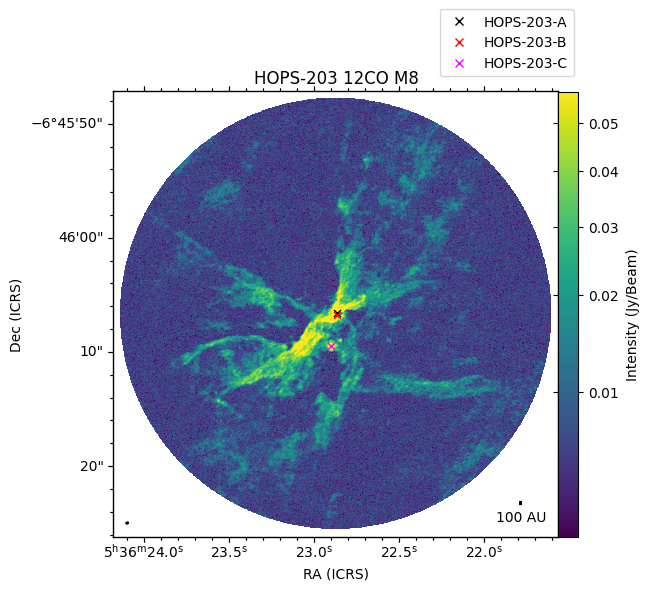

In [ ]:
# extract center coords
center_ra = hdu.header['OBSRA']
center_dec = hdu.header['OBSDEC']

# set center and size of cutout
center = SkyCoord(center_ra, center_dec, unit=u.degree)
size = np.array([39, 39]) * u.arcsecond

fig = create_m8_map(hdu, center, size, distance=target_info.iloc[0]['dis'])
fig.set_title("HOPS-203 12CO M8")
fig.show_colorscale(cmap='viridis', stretch='sqrt')

# add a marker at each source
marker_colors = ['black', 'red', 'magenta', 'darkred', 'darkblue']
legend_handles = []
for i, row in target_info.reset_index().iterrows():
    center2 = SkyCoord(row['ra'], row['dec'], unit=u.degree)
    fig.show_markers(center2.ra.deg, center2.dec.deg, coords_frame='world', marker='x', s=25, c=marker_colors[i], linewidths=1, label=row['source'])

    # Create legend handle for this source (only if not already added)
    legend_handles.append(mlines.Line2D([], [], color=marker_colors[i], marker='x', markersize=6, linestyle='None', label=row['source']))
fig.ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.05,1.2))

In [ ]:
center2

## HOPS-203 M8 Map Subplots

In [ ]:
for _, row in target.iterrows():
    # set center and size of cutout
    center = SkyCoord(row['ra'], row['dec'], unit=u.degree)
    size = np.array([2.5,2.5]) * u.arcsecond

    # plot figure
    fig = create_m8_map(hdu=hdu, center=center, size=size, distance=row['dis'])
    fig.scalebar.set_color('white')
    fig.set_title(f"{t[1]['source']} 12CO M8 Map")

## HOPS-203 All Data Cubes with Subplots of A+B and C

In [ ]:
# Generate Subplots
vmin = 5e-3; vmax = 3e-2
figure = plt.figure(figsize=(72,27))
allfitsfiles = sorted(glob.glob("../cubes/*.fits"))
for i, file in enumerate(allfitsfiles):

    print(f"Plotting {i+1}/{len(allfitsfiles)}: {file}")


    # Load image
    hdulist = fits.open(file)
    hdu = hdulist[0]

    # Create M8 Map
    m8_map = np.max(hdu.data[0,:,:,:], axis=0)

    # Collapse WCS
    wcs_original = wcs.WCS(hdu)
    wcs_2d = wcs_original.celestial
    # create a header with the wcs
    # CAUTION: lots of header data not being preserved here
    wcs_2d_header = wcs_2d.to_header()
    for key in ['BUNIT', 'OBJECT', 'TELESCOP', 'INSTRUME', 'BMAJ', 'BMIN', 'BPA']:
        if key in hdu.header:
            wcs_2d_header[key] = hdu.header[key]

    # make the full cut
    center = SkyCoord(hdu.header['OBSRA'], hdu.header['OBSDEC'], unit=u.degree)
    size = np.array([40, 40]) * u.arcsecond
    cut_full = Cutout2D(m8_map, center, size, wcs=wcs_2d)

    # combine cut and wcs and an HDU
    new_hdu_full = fits.PrimaryHDU(data=cut_full.data, header=wcs_2d_header)

    # make the sub A cut
    center = SkyCoord(hdu.header['OBSRA'], hdu.header['OBSDEC'], unit=u.degree)
    size = np.array([7.5, 7.5]) * u.arcsecond
    cut_sub_A = Cutout2D(m8_map, center, size, wcs=wcs_2d)

    # combine cut and wcs and an HDU
    new_hdu_sub_A = fits.PrimaryHDU(data=cut_sub_A.data, header=wcs_2d_header)

    # make the sub B cut
    center = SkyCoord(84.0954165, -6.7693, unit=u.degree)
    size = np.array([7.5, 7.5]) * u.arcsecond
    cut_sub_B = Cutout2D(m8_map, center, size, wcs=wcs_2d)

    # combine cut and wcs and an HDU
    new_hdu_sub_B = fits.PrimaryHDU(data=cut_sub_B.data, header=wcs_2d_header)

    # Create FITSFigure
    for j, cut_hdu in enumerate([new_hdu_full, new_hdu_sub_A, new_hdu_sub_B]):
        fig = aplpy.FITSFigure(cut_hdu, figure=figure, subplot=(3, len(allfitsfiles), i+1 + j*len(allfitsfiles)))

        # Display image
        fig.show_colorscale(cmap='viridis', stretch='sqrt', vmin=vmin, vmax=vmax)

        # Set title for column
        if j == 0:
            file_name = os.path.basename(file)
            fig.set_title(file_name)

        # Only show y-axis label and ticks on rightmost plot
        if i > 0:
            fig.axis_labels.hide_y()

        # only show x-axis label on bottom plots
        if j < 2:
            fig.axis_labels.hide_x()

        # Colorbar on leftmost plot
        # if i == len(allfitsfiles) - 1:
        fig.add_colorbar()
        fig.colorbar.set_axis_label_text("Intensity (Jy/Beam)")
        fig.colorbar.set_location('right')
        fig.colorbar.set_pad(0.0)

        # Scalebar
        fig.add_scalebar((100 / (383.5)) * u.arcsecond)
        fig.scalebar.set_label('100 AU')
        fig.scalebar.set_linewidth(3)
        if j > 0:
            fig.scalebar.set_color('white')

        # Beam
        fig.add_beam()
        fig.beam.show()
        fig.beam.set_corner("bottom left")
        fig.beam.set_color("black")
        fig.beam.set_edgecolor("black")
        fig.beam.set_facecolor("white")

plt.subplots_adjust(wspace=0.3, hspace=0)
plt.show()

figure.savefig("../results/all_m8_maps.png")